In [ ]:
!pip install simpy matplotlib pandas numpy

In [ ]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pip install simpy


In [ ]:
!pip install networkx celluloid

In [ ]:
import networkx as nx
from celluloid import Camera

In [ ]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIM_TIME = 200

# Slice configuration
slices = {
    "URLLC": {
        "bandwidth": 80,
        "priority": 1,
        "users": 20,
        "latency": [],
        "throughput": [],
        "packet_loss": 0
    },

    "eMBB": {
        "bandwidth": 80,
        "priority": 2,
        "users": 35,
        "latency": [],
        "throughput": [],
        "packet_loss": 0
    },

    "mMTC": {
        "bandwidth": 80,
        "priority": 3,
        "users": 60,
        "latency": [],
        "throughput": [],
        "packet_loss": 0
    }
}

env = simpy.Environment()

def slice_traffic(env, slice_name, user_id):

    while True:

        packet_size = random.randint(5, 50)

        congestion = slices[slice_name]["users"] / 10

        # PRIORITY SCHEDULING
        priority_factor = slices[slice_name]["priority"]

        # SLICE ISOLATION
        reserved_bw = slices[slice_name]["bandwidth"]

        delay = (packet_size / reserved_bw) * congestion * priority_factor

        # PACKET LOSS
        loss_probability = min(0.3, congestion * 0.02)

        if random.random() < loss_probability:
            slices[slice_name]["packet_loss"] += 1
            yield env.timeout(0.1)
            continue

        start = env.now

        yield env.timeout(delay)

        latency = env.now - start

        throughput = packet_size / latency

        slices[slice_name]["latency"].append(latency)
        slices[slice_name]["throughput"].append(throughput)

        yield env.timeout(random.uniform(0.2, 1.5))

# Start users
for slice_name in slices:

    for i in range(slices[slice_name]["users"]):

        env.process(slice_traffic(env, slice_name, i))

env.run(until=SIM_TIME)

In [ ]:
results = []

for s in slices:

    avg_latency = np.mean(slices[s]["latency"])
    avg_throughput = np.mean(slices[s]["throughput"])
    packet_loss = slices[s]["packet_loss"]

    results.append([
        s,
        avg_latency,
        avg_throughput,
        packet_loss
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Slice",
        "Avg Latency",
        "Avg Throughput",
        "Packet Loss"
    ]
)

print(df)

   Slice  Avg Latency  Avg Throughput  Packet Loss
0  URLLC     0.684679       40.000000          112
1   eMBB     2.355397       11.428571          149
2   mMTC     6.207456        4.444444          252


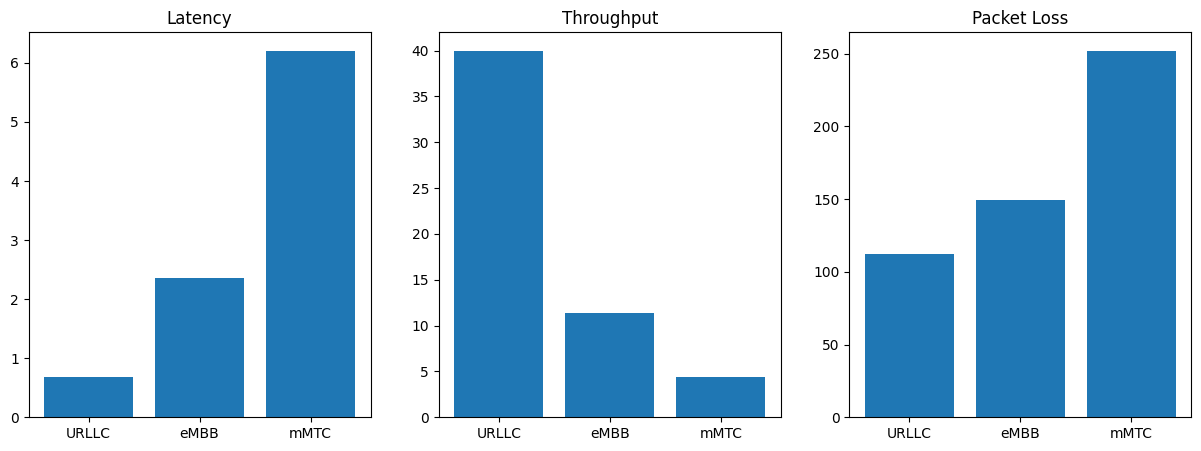

In [ ]:
plt.figure(figsize=(15,5))

# LATENCY
plt.subplot(1,3,1)
plt.bar(df["Slice"], df["Avg Latency"])
plt.title("Latency")

# THROUGHPUT
plt.subplot(1,3,2)
plt.bar(df["Slice"], df["Avg Throughput"])
plt.title("Throughput")

# PACKET LOSS
plt.subplot(1,3,3)
plt.bar(df["Slice"], df["Packet Loss"])
plt.title("Packet Loss")

plt.show()

In [ ]:
# WITHOUT SLICING SIMULATION

total_bandwidth = 240

without_slicing_latency = []
without_slicing_throughput = []

for i in range(100):

    packet_size = random.randint(5, 50)

    congestion = 100 / 10

    delay = (packet_size / total_bandwidth) * congestion

    latency = delay

    throughput = packet_size / latency

    without_slicing_latency.append(latency)
    without_slicing_throughput.append(throughput)

print("WITHOUT SLICING")

print("Average Latency:",
      np.mean(without_slicing_latency))

print("Average Throughput:",
      np.mean(without_slicing_throughput))

WITHOUT SLICING
Average Latency: 1.1737499999999998
Average Throughput: 24.0



SLICE PERFORMANCE

   Slice  Avg Latency  Avg Throughput  Packet Loss Rate
0  URLLC     0.366079       75.000000          0.041606
1   eMBB     0.322322       85.714286          0.070291
2   mMTC     0.367501       75.000000          0.122489

COMPARISON RESULTS

          Scenario   Latency  Throughput
0     With Slicing  0.353236   78.214286
1  Without Slicing  0.666279   43.000000


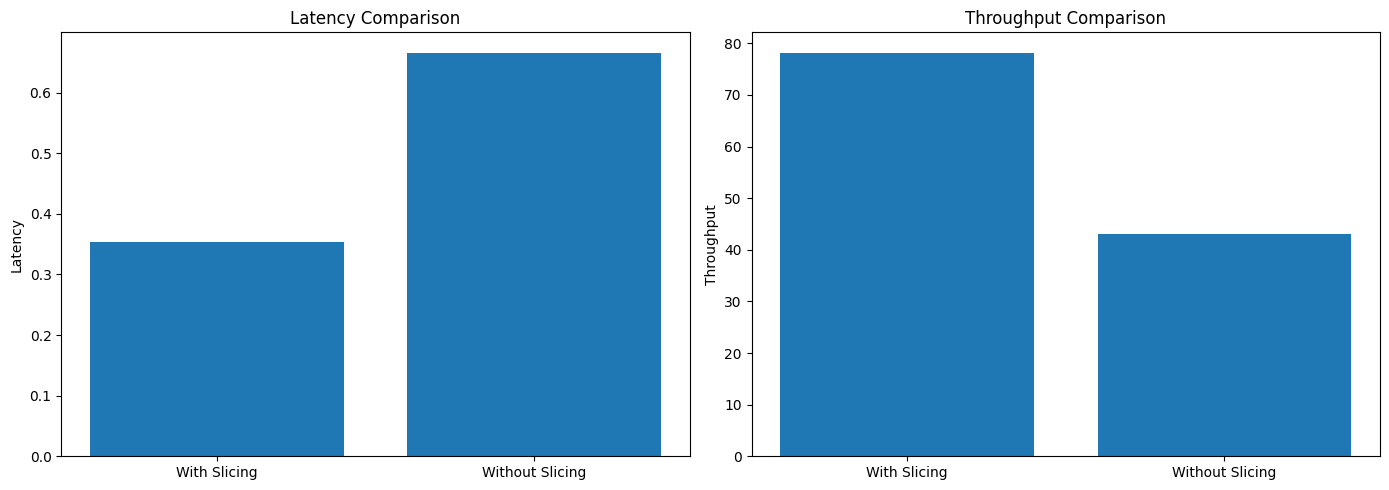

In [ ]:
import simpy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SIMULATION TIME
SIM_TIME = 200

# 5G SLICES
slices = {
    "URLLC": {"bandwidth": 150, "priority": 1, "users": 20,
              "latency": [], "throughput": [], "packet_loss": 0, "total_packets": 0},
    "eMBB": {"bandwidth": 150, "priority": 2, "users": 35,
             "latency": [], "throughput": [], "packet_loss": 0, "total_packets": 0},
    "mMTC": {"bandwidth": 150, "priority": 3, "users": 60,
             "latency": [], "throughput": [], "packet_loss": 0, "total_packets": 0}
}

# CREATE ENVIRONMENT
env = simpy.Environment()

# TRAFFIC FUNCTION
def slice_traffic(env, slice_name, user_id):
    while True:
        packet_size = random.randint(5, 50)
        congestion = slices[slice_name]["users"] / 10
        priority_factor = slices[slice_name]["priority"]
        reserved_bw = slices[slice_name]["bandwidth"]

        # Delay equation (avoid division by zero)
        delay = max(0.001, (packet_size / reserved_bw) * congestion / priority_factor)

        # Packet loss probability
        loss_probability = min(0.3, congestion * 0.02)
        slices[slice_name]["total_packets"] += 1

        if random.random() < loss_probability:
            slices[slice_name]["packet_loss"] += 1
            yield env.timeout(0.1)
            continue

        start = env.now
        yield env.timeout(delay)
        latency = env.now - start
        throughput = packet_size / latency

        slices[slice_name]["latency"].append(latency)
        slices[slice_name]["throughput"].append(throughput)

        yield env.timeout(random.uniform(0.2, 1.5))

# START USERS
for slice_name in slices:
    for i in range(slices[slice_name]["users"]):
        env.process(slice_traffic(env, slice_name, i))

# RUN SIMULATION
env.run(until=SIM_TIME)

# RESULTS TABLE
results = []
for s in slices:
    avg_latency = np.mean(slices[s]["latency"])
    avg_throughput = np.mean(slices[s]["throughput"])
    packet_loss_rate = slices[s]["packet_loss"] / slices[s]["total_packets"] if slices[s]["total_packets"] > 0 else 0

    results.append([s, avg_latency, avg_throughput, packet_loss_rate])

df = pd.DataFrame(results, columns=["Slice", "Avg Latency", "Avg Throughput", "Packet Loss Rate"])
print("\nSLICE PERFORMANCE\n")
print(df)

# WITHOUT SLICING
total_bandwidth = 430
without_slicing_latency = []
without_slicing_throughput = []

for i in range(100):
    packet_size = random.randint(5, 50)
    congestion = 100 / 10
    delay = max(0.001, (packet_size / total_bandwidth) * congestion)
    latency = delay
    throughput = packet_size / latency
    without_slicing_latency.append(latency)
    without_slicing_throughput.append(throughput)

# WEIGHTED QOS COMPARISON
weights = {"URLLC": 0.5, "eMBB": 0.3, "mMTC": 0.2}

with_slicing_latency = sum(df.loc[df["Slice"] == s, "Avg Latency"].values[0] * w for s, w in weights.items())
with_slicing_throughput = sum(df.loc[df["Slice"] == s, "Avg Throughput"].values[0] * w for s, w in weights.items())

comparison = pd.DataFrame({
    "Scenario": ["With Slicing", "Without Slicing"],
    "Latency": [with_slicing_latency, np.mean(without_slicing_latency)],
    "Throughput": [with_slicing_throughput, np.mean(without_slicing_throughput)]
})

print("\nCOMPARISON RESULTS\n")
print(comparison)

# FINAL VISUALIZATION
plt.figure(figsize=(14, 5))

# LATENCY
plt.subplot(1, 2, 1)
plt.bar(comparison["Scenario"], comparison["Latency"])
plt.ylabel("Latency")
plt.title("Latency Comparison")

# THROUGHPUT
plt.subplot(1, 2, 2)
plt.bar(comparison["Scenario"], comparison["Throughput"])
plt.ylabel("Throughput")
plt.title("Throughput Comparison")

plt.tight_layout()
plt.show()
